# Introducción a RAG

Retrieval-Augmented Generation combina la búsqueda de información con un LLM para que sus respuestas se basen en los datos de la base de datos vectorial en lugar de solo en lo que aprendió durante su entrenamiento.


<div style="width:500px">

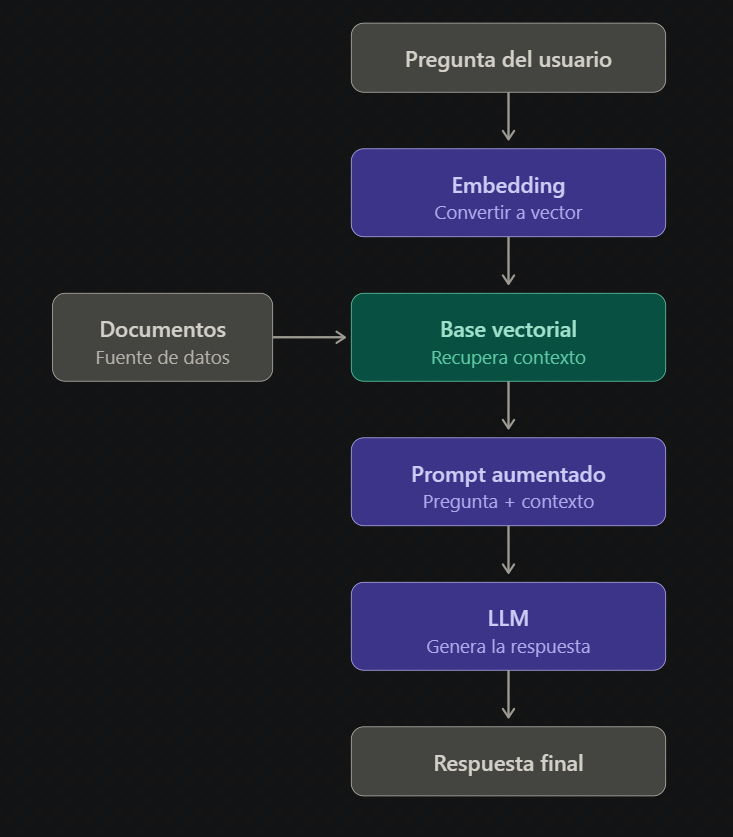

</div>

- Retriever: Embedding + Documentos + Recuperación de Texto
- Augmented: Prompt Aumentado
- Generation: Generación basada en prompt aumentado.

In [ ]:
# pip install langchain langgraph
# pip uninstall easyocr # eliminar si no se desea multimodalidad, caso contrario, instalar librerías sugeridas
# pip uninstall scikit-image # eliminar si no se desea multimodalidad, caso contrario, instalar librerías sugeridas
# pip install chromadb
# pip install sentence-transformers

In [48]:
import os

import numpy as np

import langchain
from langchain_openai import ChatOpenAI

from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb import Documents, EmbeddingFunction, Embeddings
from chromadb.utils import embedding_functions

from dotenv import load_dotenv

openai_key = os.getenv("OPENAI_KEY")

In [3]:
# OpenAI LangChain conection example
llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-5.4-mini"),
    api_key=os.getenv("OPENAI_KEY"),
    temperature=0.7,
        model_kwargs={
        "reasoning_effort": "medium"
    }
)

response = llm.invoke("What is the capital of France?")
print(response.content) 

/Users/user/miniforge3/envs/lang/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3688: UserWarning: Parameters {'reasoning_effort'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


The capital of France is **Paris**.


## Base de Datos Vectorial

In [18]:
# Taken from: https://github.com/chroma-core/chroma
## setup Chroma in-memory, for easy prototyping. Can add persistence easily!
client = chromadb.Client()

## Create collection. get_collection, get_or_create_collection, delete_collection also available!
try:
    client.delete_collection(name="all-my-documents")
except Exception:
    pass

collection = client.get_or_create_collection(
    name="all-my-documents",
    metadata={"hnsw:space": "cosine"} 
)

## Add docs to the collection. Can also update and delete. Row-based API coming soon!
## chromadb uses all-MiniLM-L6-v2 embedding by default
collection.add(
    documents=["This is document1", "This is document2"], # we handle tokenization, embedding, and indexing automatically. You can skip that and add your own embeddings as well
        # OJO: chunking se debe hacer manualmente
    metadatas=[{"source": "notion"}, {"source": "google-docs"}], # filter on these(?)
    ids=["doc1", "doc2"], # unique for each doc
)

## Query/search 2 most similar results. You can also .get by id
results = collection.query(
    query_texts=["document1"],
    n_results=2 # hiper-parámetro por optimizar
    # where={"metadata_field": "is_equal_to_this"}, # optional filter
    # where_document={"$contains":"search_string"}  # optional filter
)
print(results)

{'ids': [['doc1', 'doc2']], 'embeddings': None, 'documents': [['This is document1', 'This is document2']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'source': 'notion'}, {'source': 'google-docs'}]], 'distances': [[0.1271592378616333, 0.247614324092865]]}


Detalle importante sobre las distancias de ChromaDB:

**Similitud coseno** (cosine similarity):

$$\text{sim}(a, b) = \frac{a \cdot b}{\|a\| \|b\|} \in [-1, 1]$$

- 1 = vectores idénticos en dirección
- 0 = ortogonales
- -1 = opuestos

**Distancia coseno** (cosine distance), como la define Chroma:

$$d(a, b) = 1 - \text{sim}(a, b) \in [0, 2]$$

- 0 = idénticos
- 1 = ortogonales
- 2 = opuestos


## Métricas para retriever

Según Enevoldsen et al. (2025) se recomienda tres métricas para medir la calidad de un retriever:

- **Precision@k**: de los k documentos que recuperaste, ¿qué fracción es relevante?
- **Recall@k**: de todos los documentos relevantes que existen, ¿qué fracción capturaste en el top-k?
- **nDCG@k**: de los k documentos que recuperaste, ¿qué tan bien están *ordenados* por relevancia?

Formalmente:

**Precision@k:**

$$P@k = \frac{|\{d_1, \ldots, d_k\} \cap R_q|}{k}$$

**Recall@k:**

$$R@k = \frac{|\{d_1, \ldots, d_k\} \cap R_q|}{|R_q|}$$

En este contexto, Precision y Recall se diferencian por el denominador: Precision divide por k (cuántos documentos vemos), Recall divide por |R_q| (cuántos relevantes existen en total).

El top de MTEB basado en nDCG@k propuesto por  Enevoldsen et al. (2025) se puede encontrar en: https://huggingface.co/spaces/mteb/leaderboard el cual se encuentra constantemente evolucionando. Por esa razón los autores sugieren su uso como una referencia inicial únicamente. Recuerda comparar métricas de desempeño con costo y latencia, ¿la mejora en desempeño vale la pena desde un punto de vista de costo?

In [53]:
# Cambiar de embedding

client = chromadb.Client()

## Create collection. get_collection, get_or_create_collection, delete_collection also available!
try:
    client.delete_collection(name="all-my-documents")
except Exception:
    pass

model = SentenceTransformer(
    "microsoft/harrier-oss-v1-0.6b",
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager", "torch_dtype": "bfloat16"},
    tokenizer_kwargs={"padding_side": "left"}, # hiper-parámetros recomendados por autores: https://huggingface.co/nvidia/llama-embed-nemotron-8b
)

class NewEmbeddingFunction(EmbeddingFunction):
    def __init__(self):
        self.model = SentenceTransformer(
            "microsoft/harrier-oss-v1-0.6b",
            trust_remote_code=True,
            model_kwargs={"attn_implementation": "eager", "torch_dtype": "bfloat16"},
            tokenizer_kwargs={"padding_side": "left"},  # hiper-parámetros recomendados por autores: https://huggingface.co/nvidia/llama-embed-nemotron-8b
        )

    def __call__(self, input: Documents) -> Embeddings:
        return self.model.encode(input).tolist()

    @staticmethod
    def name() -> str:
        return "harrier-oss-v1-0.6b"

ef = NewEmbeddingFunction()

collection = client.get_or_create_collection(
    name="all-my-documents",
    metadata={"hnsw:space": "cosine"},
    embedding_function=ef,
)
del collection
import gc

gc.collect()

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 16135.74it/s]


258

# Tarea en clase

Construir un RAG con LangChain y su LLM favorito, use los documentos provistos, ¿su RAG puede responder correctamente todas estas preguntas? - pruebe differentes embeddings

**Multi-hop (encadenar varios documentos):**
- *"¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar?"* → acta → LR-100 → 90 min.
- *"¿Qué versión de la app necesito para el modelo que reemplazó al LR-100?"* → acta → LR-200 specs → v3.x.

**Temporal y condicional (dos políticas vigentes en distintos momentos):**
- *"Compré un LR-200 sin abrir hace 45 días, ¿puedo devolverlo y con qué cargo?"* → política 2024 → reembolso íntegro sin cargo.
- *"¿Y si lo hubiera comprado en febrero de 2024?"* → política 2023 → 30 días, ya fuera de plazo.

**Routing (elegir el canal correcto según el problema):**
- *"Mi LR-200 muestra error E07 que no se va al reiniciar, ¿a quién llamo?"* → incidencias dicen "fallo de hardware" → contactos → +34 900 111 222.
- *"Tengo garantía extendida y mi LR-200 no enciende, ¿qué línea uso?"* → línea preferente.

**Comparación cruzada:**
- *"¿Qué modelo del mercado ofrece mejor garantía por menos de 600 €?"* → comparativa + tabla de garantías → LR-200.

**Agregación con filtrado:**
- *"Lista todos los bugs de software del modelo estrella que ya estén resueltos."* → identificar "estrella" = LR-200 → filtrar resueltos → F-301.

El truco está en que cada documento por sí solo es insuficiente: el sistema tiene que decidir **qué consultar**, **en qué orden** y **cuándo combinar resultados** — justo lo que un agente sabe hacer y un retriever de un solo paso no.

In [57]:
# Paso 1) Crear base vectorial
all_txt_files = os.listdir("data")
all_txt_files = [i for i in all_txt_files if "txt" in i]
print(all_txt_files)

client = chromadb.Client()

try:
    client.delete_collection(name="all-my-documents-1")
except Exception:
    pass

try:
    client.delete_collection(name="all-my-documents-2")
except Exception:
    pass

try:
    client.delete_collection(name="all-my-documents-3")
except Exception:
    pass

collection_1 = client.get_or_create_collection(
    name="all-my-documents-1",
    metadata={"hnsw:space": "cosine"} 
)

collection_2 = client.get_or_create_collection(
    name="all-my-documents-2",
    metadata={"hnsw:space": "cosine"},
    embedding_function=ef,
)
ef_openai = embedding_functions.OpenAIEmbeddingFunction(
    api_key=os.environ["OPENAI_KEY"],
    model_name="text-embedding-3-large",
)

collection_3 = client.get_or_create_collection(
    name="all-my-documents-3",
    metadata={"hnsw:space": "cosine"},
    embedding_function=ef_openai,
)


splitter = RecursiveCharacterTextSplitter(
    chunk_size=250,        # caracteres, no tokens
    chunk_overlap=25,      # solapamiento para no cortar ideas
    separators=["\n\n", "\n", ". ", " ", ""],
)

total_chunks = 0 
for file in all_txt_files:
    with open(os.path.join("data",file), "r", encoding="utf-8") as f:
        document_i = f.read()
    chunks = splitter.split_text(document_i)
    collection_1.add(
        documents=chunks,
        ids= [f"{file}_{i}" for i in range(len(chunks))]
    )
    total_chunks += len(chunks)

for file in all_txt_files:
    with open(os.path.join("data",file), "r", encoding="utf-8") as f:
        document_i = f.read()
    chunks = splitter.split_text(document_i)
    collection_2.add(
        documents=chunks,
        ids= [f"{file}_{i}" for i in range(len(chunks))]
    )

for file in all_txt_files:
    with open(os.path.join("data",file), "r", encoding="utf-8") as f:
        document_i = f.read()
    chunks = splitter.split_text(document_i)
    collection_3.add(
        documents=chunks,
        ids= [f"{file}_{i}" for i in range(len(chunks))]
    )

# paso 2) conexión a LLM
llm = ChatOpenAI(
    model=os.getenv("OPENAI_MODEL", "gpt-5.4-mini"),
    api_key=os.getenv("OPENAI_KEY"),
    temperature=0,
        model_kwargs={
        "reasoning_effort": "medium"
    }
)

response = llm.invoke("What is the capital of France?")
print(f"{response.content=}") 

# Paso 3) RAG function
def rag_simple(human_query, collection, top_k=2):
    retriever_result = collection.query(
        query_texts=human_query,
        n_results=top_k
    )
    augmented_prompt = "<human_query>" + human_query + "</human_query>"
    augmented_prompt += "<retriever_results>"
    for i in range(len(retriever_result['ids'][0])):
        
        augmented_prompt += "<doc_id>" + retriever_result['ids'][0][i] + "</doc_id>" 
        augmented_prompt += "<chunk>" + retriever_result['documents'][0][i] +  "</chunk>" 
    augmented_prompt += "</retriever_results>"

    mensajes = [
        SystemMessage("Eres un sistema RAG experto, responde la pregunta del usuario basado en los chunks. " \
        "Tus respuestas son lo más corta posibles y precisas. No parafrases"),
        HumanMessage(augmented_prompt),
    ]
    cadena = llm | StrOutputParser()

    response = cadena.invoke(mensajes)

    return response

print(f"{total_chunks=}")

['08_manual_uso_lr200.txt', '02_producto_lr200_specs.txt', '06_garantias.txt', '10_comparativa_competencia.txt', '03_politica_devoluciones_2023.txt', '07_soporte_contactos.txt', '05_acta_reunion_q3_2024.txt', '01_producto_lr100_specs.txt', '04_politica_devoluciones_2024.txt', '09_incidencias_conocidas.txt']


/Users/user/miniforge3/envs/lang/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3688: UserWarning: Parameters {'reasoning_effort'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


response.content='The capital of France is **Paris**.'
total_chunks=53


In [58]:
rag_response = rag_simple(
    "¿Qué versión de la app necesito para el modelo que reemplazó al LR-100",
     collection= collection_1,
     top_k = 20)
print(rag_response)
print("v3.x" in rag_response)

Lumina Home v3.x o superior.
True


In [59]:
rag_response = rag_simple(
    "¿Qué versión de la app necesito para el modelo que reemplazó al LR-100",
     collection= collection_2,
     top_k = 20)
print(rag_response)
print("v3.x" in rag_response)

Lumina Home **v3.x o superior**.
True


In [64]:
lista_preguntas = [
    "¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar?",
    "Qué versión de la app necesito para el modelo que reemplazó al LR-100",
    "Compré un LR-200 sin abrir hace 45 días, ¿puedo devolverlo y con qué cargo?",
    "Compré un LR-200 sin abrir en febrero de 2024, ¿puedo devolverlo y con qué cargo?",
    "Mi LR-200 muestra error E07 que no se va al reiniciar, ¿a quién llamo?",
    "Tengo garantía extendida y mi LR-200 no enciende, ¿qué línea uso?",
    "¿Qué modelo del mercado ofrece mejor garantía por menos de 600 €?",
    "Lista todos los bugs de software del modelo estrella que ya estén resueltos."    
]
lista_respuestas = [
    "90 min",
    "v3.x",
    "reembolso íntegro sin cargo",
    "ya fuera de plazo.",
    "+34 900 111 222",
    "línea preferente",
    "LR-200",
    "F-301"    
]

quality_results = []
for i in range(len(lista_preguntas)):
    #print("="*50)
    rag_response = rag_simple(lista_preguntas[i], collection_1, top_k = 20)
    #print(lista_preguntas[i], "->", lista_respuestas[i], "->", rag_response,lista_respuestas[i] in rag_response)
    quality_results.append(lista_respuestas[i].lower() in rag_response.lower())

print("Prop. of correct answers - embedding 1: ", np.mean(quality_results))


quality_results = []
for i in range(len(lista_preguntas)):
    print("="*50)
    rag_response = rag_simple(lista_preguntas[i], collection_2, top_k = 20)
    print(lista_preguntas[i], "->", lista_respuestas[i], "->", rag_response,lista_respuestas[i] in rag_response)
    quality_results.append(lista_respuestas[i].lower() in rag_response.lower())

print("Prop. of correct answers - embedding 2: ", np.mean(quality_results))



quality_results = []
for i in range(len(lista_preguntas)):
    #print("="*50)
    rag_response = rag_simple(lista_preguntas[i], collection_3, top_k = 20)
    #print(lista_preguntas[i], "->", lista_respuestas[i], "->", rag_response,lista_respuestas[i] in rag_response)
    quality_results.append(lista_respuestas[i].lower() in rag_response.lower())

print("Prop. of correct answers - embedding 3: ", np.mean(quality_results))

Prop. of correct answers - embedding 1:  0.5
¿Qué autonomía tiene el modelo que el CTO recomendó discontinuar? -> 90 min -> No consta en los chunks. False
Qué versión de la app necesito para el modelo que reemplazó al LR-100 -> v3.x -> Lumina Home 3.x o superior. False
Compré un LR-200 sin abrir hace 45 días, ¿puedo devolverlo y con qué cargo? -> reembolso íntegro sin cargo -> Sí. **“Sin abrir: reembolso íntegro, sin cargos adicionales.”**  
**“Plazo: 60 días naturales desde la recepción del producto.”** False
Compré un LR-200 sin abrir en febrero de 2024, ¿puedo devolverlo y con qué cargo? -> ya fuera de plazo. -> Comprado en febrero de 2024: aplica la política 2023, con **30 días naturales desde la recepción**.  
**Cargo por reposición: 15% solo si ha sido abierto**. False
Mi LR-200 muestra error E07 que no se va al reiniciar, ¿a quién llamo? -> +34 900 111 222 -> Llama a la línea preferente para incidencias críticas del LR-200: **+34 900 333 444** (**lun-dom, 8:00–22:00**). False
Te

# Referencias

Enevoldsen, K., Chung, I., Kerboua, I., Kardos, M., Mathur, A., Stap, D., ... & Muennighoff, N. (2025). Mmteb: Massive multilingual text embedding benchmark. arXiv preprint arXiv:2502.13595.